In [ ]:
# Fetch stock summary data and store in SQLite database
import requests
from datetime import date
import sqlite3
import yfinance as yf
import pandas as pd

# create a database connection
conn = sqlite3.connect('stocks_summary.db')
c = conn.cursor()

headers = {
  "User-Agent": "Mozilla/5.0 (Compatible; MyAgent/1.0; +)",
  "Referer": "https://www.idx.co.id/id/data-pasar/ringkasan-perdagangan/ringkasan-saham/",
  "sec-ch-ua-platform": '"Linux"',
}

# today = date.today()
today = date(2026, 1, 2)

def get_stock_sector_industry(ticker):
  # select from DB first, if not found, fetch from idx.co.id
  c.execute('SELECT DISTINCT ticker, sector, industry FROM stocks_summary_yf WHERE ticker = ?', (ticker,))
  row = c.fetchone()
  if row:
    return row[1], row[2]
  else:
    print(f"Fetching sector and industry for {ticker} from IDX...")
    headers['Referer'] = f"https://www.idx.co.id/en/listed-companies/company-profiles/{ticker}"
    response = requests.get(f"https://www.idx.co.id/primary/ListedCompany/GetCompanyProfilesDetail?KodeEmiten={ticker}&language=en-us", headers=headers)
    data = response.json()
    profile = data['Profiles'][0]
    return profile.get('Sektor', None), profile.get('Industri', None)

stock_summary_response = requests.get(
  f"https://www.idx.co.id/primary/TradingSummary/GetStockSummary?length=9999&start=0&date={today.strftime('%Y%m%d')}",
  headers=headers
)
if stock_summary_response.status_code == 200:
  data = stock_summary_response.json()['data']
  
  if len(data) == 0:
    print("Belum ada data untuk hari ini.")

  for item in data:
    if item['StockCode'] in ['GOTOM', 'CNTB']:
      continue  # skip non-stock items
    
    sector, industry = get_stock_sector_industry(item['StockCode'])
    filtered = {
      'date': today.strftime('%Y-%m-%d'),
      'ticker': item['StockCode'],
      'sector': sector,
      'industry': industry,
      'volume': item['Volume'],
      'value': item['Value'],
      'frequency': item['Frequency'],
      'offer': item['Offer'],
      'offer_volume': item['OfferVolume'],
      'bid': item['Bid'],
      'bid_volume': item['BidVolume'],
      'foreign_buy': item['ForeignBuy'],
      'foreign_sell': item['ForeignSell'],
      'is_suspended': item['OpenPrice'] == 0 and item['High'] == 0 and item['Low'] == 0 and item['Volume'] == 0,
    }
    hist = yf.Ticker(item['StockCode'] + '.JK').history(start=today.strftime('%Y-%m-%d'), end=(today + pd.Timedelta(days=1)).strftime('%Y-%m-%d'))
    filtered.update({
      'open': hist['Open'].values[0] if not hist.empty else 0,
      'high': hist['High'].values[0] if not hist.empty else 0,
      'low': hist['Low'].values[0] if not hist.empty else 0,
      'close': hist['Close'].values[0] if not hist.empty else 0,
    })
    
    c.execute('''INSERT OR IGNORE INTO stocks_summary_yf
            (date, ticker, sector, industry, open, high, low, close, volume, value, frequency, offer, offer_volume, bid, bid_volume, foreign_buy, foreign_sell, is_suspended)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)''',
            (filtered['date'], filtered['ticker'], filtered['sector'], filtered['industry'], filtered['open'], filtered['high'], filtered['low'], filtered['close'], filtered['volume'], filtered['value'], filtered['frequency'],
            filtered['offer'], filtered['offer_volume'], filtered['bid'], filtered['bid_volume'], filtered['foreign_buy'], filtered['foreign_sell'], filtered['is_suspended'])
          )
  conn.commit()

In [1]:
# Verify inserted data
import sqlite3

# create a database connection
conn = sqlite3.connect('stocks_summary.db')
c = conn.cursor()

# select from the table
c.execute('SELECT * FROM stocks_summary_yf WHERE open > 0')
rows = c.fetchall()

print(len(rows))

1179886


In [2]:
# Feature engineering
import pandas as pd
import numpy as np

# set display options to show all columns
pd.set_option('display.max_columns', None)
# set float format to 2 decimal places
pd.set_option('display.float_format', '{:.2f}'.format)

# convert to DataFrame for easier handling
df = pd.DataFrame(rows, columns=[desc[0] for desc in c.description])
# set index to date and ticker
df.drop('id', axis=1, inplace=True)
df.set_index(['date', 'ticker'], inplace=True)

# starting columns are:
# date, ticker, sector, industry, open, high, low, close, volume, value, frequency, offer, offer_volume, bid, bid_volume, foreign_buy, foreign_sell, is_suspended

# Feature engineering
df['bid_offer_ratio'] = (df['bid_volume'] / df['offer_volume']).fillna(0).replace([np.inf, -np.inf], np.nan)
df['bid_offer_ratio'] = df['bid_offer_ratio'].fillna(df['bid_offer_ratio'].quantile(1))
df['volume_change'] = df.groupby(level=1)['volume'].diff().fillna(0)
df['volume_change_pct'] = (df['volume_change'] / df.groupby(level=1)['volume'].shift(1)).replace([np.inf, -np.inf], 0).fillna(0)
df['value_change'] = df.groupby(level=1)['value'].diff().fillna(0)
df['value_change_pct'] = (df['value_change'] / df.groupby(level=1)['value'].shift(1)).replace([np.inf, -np.inf], 0).fillna(0)
df['frequency_change'] = df.groupby(level=1)['frequency'].diff().fillna(0)
df['frequency_change_pct'] = (df['frequency_change'] / df.groupby(level=1)['frequency'].shift(1)).replace([np.inf, -np.inf], 0).fillna(0)
df['foreign_net'] = df['foreign_buy'] - df['foreign_sell']
df['foreign_gross'] = df['foreign_buy'] + df['foreign_sell']
df['foreign_vol_ratio'] = (df['foreign_gross'] / df['volume']).replace([np.inf, -np.inf], 0).fillna(0)
df['foreign_net_ratio'] = (df['foreign_buy'] / df['foreign_sell']).replace([np.inf, -np.inf], 0).fillna(0)
df['price_change'] = df.groupby(level=1)['close'].diff().fillna(0)
df['price_change_pct'] = (df['price_change'] / df.groupby(level=1)['close'].shift(1)).fillna(0)
df['price_volatility'] = (df['high'] - df['low']) / df['open']
df['pre_market_gap'] = (df['open'] - df.groupby(level=1)['close'].shift(1)).fillna(0)
df['pre_market_gap_pct'] = (df['pre_market_gap'] / df.groupby(level=1)['close'].shift(1)).fillna(0)

df = df.copy()

# average & std dev of daily volume, value, frequency, foreign flow over past x days
for x in [3, 5, 10, 21]:
  df[f'avg_volume_{x}'] = df.groupby(level=1)['volume'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'avg_value_{x}'] = df.groupby(level=1)['value'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'avg_frequency_{x}'] = df.groupby(level=1)['frequency'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'avg_foreign_net_{x}'] = df.groupby(level=1)['foreign_net'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'avg_foreign_gross_{x}'] = df.groupby(level=1)['foreign_gross'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'avg_foreign_vol_ratio_{x}'] = df.groupby(level=1)['foreign_vol_ratio'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'avg_foreign_net_ratio_{x}'] = df.groupby(level=1)['foreign_net_ratio'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'avg_volume_change_pct_{x}'] = df.groupby(level=1)['volume_change_pct'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'avg_value_change_pct_{x}'] = df.groupby(level=1)['value_change_pct'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'avg_frequency_change_pct_{x}'] = df.groupby(level=1)['frequency_change_pct'].transform(lambda s: s.rolling(window=x, min_periods=1).mean())
  df[f'std_volume_{x}'] = df.groupby(level=1)['volume'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'std_value_{x}'] = df.groupby(level=1)['value'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'std_frequency_{x}'] = df.groupby(level=1)['frequency'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'std_foreign_net_{x}'] = df.groupby(level=1)['foreign_net'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'std_foreign_gross_{x}'] = df.groupby(level=1)['foreign_gross'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'std_foreign_vol_ratio_{x}'] = df.groupby(level=1)['foreign_vol_ratio'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'std_foreign_net_ratio_{x}'] = df.groupby(level=1)['foreign_net_ratio'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'std_volume_change_pct_{x}'] = df.groupby(level=1)['volume_change_pct'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'std_value_change_pct_{x}'] = df.groupby(level=1)['value_change_pct'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'std_frequency_change_pct_{x}'] = df.groupby(level=1)['frequency_change_pct'].transform(lambda s: s.rolling(window=x, min_periods=1).std())
  df[f'higher_price_{x}'] = df.groupby(level=1)['high'].shift(1).rolling(window=x, min_periods=1).max()
  df[f'lower_price_{x}'] = df.groupby(level=1)['low'].shift(1).rolling(window=x, min_periods=1).min()
  df[f'price_change_{x}'] = df['close'] - df.groupby(level=1)['close'].shift(x)
  df[f'price_change_pct_{x}'] = (df[f'price_change_{x}'] / df.groupby(level=1)['close'].shift(x)).fillna(0)
  df[f'log_return_{x}'] = np.log(df['close'] / df.groupby(level=1)['close'].shift(x)).fillna(0)

df['is_ara'] = ((df['offer'] == 0) & (df['bid'] > 0)).astype(int)
df['is_arb'] = ((df['bid'] == 0) & (df['offer'] > 0)).astype(int)
# if price < 200, tick size is 1
# if price >= 200 and < 500, tick size is 2
# if price >= 500 and < 2000, tick size is 5
# if price >= 2000 and < 5000, tick size is 10
# if price >= 5000, tick size is 25
if 'tick_size' not in df.columns:
  df['tick_size'] = np.select(
    [
      df['close'] < 200,
      (df['close'] >= 200) & (df['close'] < 500),
      (df['close'] >= 500) & (df['close'] < 2000),
      (df['close'] >= 2000) & (df['close'] < 5000),
      df['close'] >= 5000
    ],
    [1, 2, 5, 10, 25],
    default=1
  )

date_index = pd.to_datetime(df.index.get_level_values(0))
df['day_of_week'] = date_index.dayofweek
df['month'] = date_index.month

# target variable: if in the next 5 tradings days, the high increases by at least 10%, and low never drops by more than 5%
df['target'] = 0
for i in range(1, 6):
  future_high = df.groupby(level=1)['high'].shift(-i)
  future_low = df.groupby(level=1)['low'].shift(-i)
  condition = (future_high >= df['close'] * 1.10) & (future_low >= df['close'] * 0.95)
  df.loc[condition, 'target'] = 1

df.dropna(inplace=True)
df.head()

C:\Users\rizbud\AppData\Local\Temp\ipykernel_16120\368019158.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'price_change_{x}'] = df['close'] - df.groupby(level=1)['close'].shift(x)
C:\Users\rizbud\AppData\Local\Temp\ipykernel_16120\368019158.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'price_change_pct_{x}'] = (df[f'price_change_{x}'] / df.groupby(level=1)['close'].shift(x)).fillna(0)
C:\Users\rizbud\AppData\Local\Temp\ipykernel_16120\368019158.py:66: PerformanceWarning: DataFrame is highly fragmented.  T

sector               industry     open  \
date       ticker                                                           
2020-01-31 AALI    Consumer Non-Cyclicals  Agricultural Products 11925.00   
           ABBA        Consumer Cyclicals                  Media    61.00   
           ABDA                Financials              Insurance  6800.00   
           ABMM                    Energy                   Coal  1445.00   
           ACES        Consumer Cyclicals       Specialty Retail  1565.00   

                      high      low    close    volume        value  \
date       ticker                                                     
2020-01-31 AALI   11925.00 11525.00 11875.00    457500   5336775000   
           ABBA      65.00    60.00    60.00   6361400    492962900   
           ABDA    6800.00  6800.00  6800.00         0            0   
           ABMM    1445.00  1445.00  1445.00         0            0   
           ACES    1720.00  1530.00  1720.00  45764800  74856955000   

                   frequency    offer  offer_volume      bid  bid_volume  \
date       ticker                                                          
2020-01-31 AALI          736 11875.00         29100 11775.00        2300   
           ABBA          967    77.00        603100    76.00      266400   
           ABDA            0  7000.00        802700  5450.00         100   
           ABMM            0  1445.00           300  1160.00        8400   
           ACES         4380  1720.00       3502700  1715.00      390000   

                   foreign_buy  foreign_sell  is_suspended  bid_offer_ratio  \
date       ticker                                                             
2020-01-31 AALI         160600         38300             0             0.08   
           ABBA              0             0             0             0.44   
           ABDA              0             0             1             0.00   
           ABMM              0             0             1            28.00   
           ACES        6807700      22765700             0             0.11   

                   volume_change  volume_change_pct   value_change  \
date       ticker                                                    
2020-01-31 AALI       -576900.00              -0.56 -6925705000.00   
           ABBA      -6676000.00              -0.51  -565735000.00   
           ABDA             0.00               0.00           0.00   
           ABMM             0.00               0.00           0.00   
           ACES      38733600.00               5.51 63842839000.00   

                   value_change_pct  frequency_change  frequency_change_pct  \
date       ticker                                                             
2020-01-31 AALI               -0.56           -522.00                 -0.41   
           ABBA               -0.53            192.00                  0.25   
           ABDA                0.00              0.00                  0.00   
           ABMM                0.00              0.00                  0.00   
           ACES                5.80           2284.00                  1.09   

                   foreign_net  foreign_gross  foreign_vol_ratio  \
date       ticker                                                  
2020-01-31 AALI         122300         198900               0.43   
           ABBA              0              0               0.00   
           ABDA              0              0               0.00   
           ABMM              0              0               0.00   
           ACES      -15958000       29573400               0.65   

                   foreign_net_ratio  price_change  price_change_pct  \
date       ticker                                                      
2020-01-31 AALI                 4.19        -50.00             -0.00   
           ABBA                 0.00         -4.00             -0.06   
           ABDA                 0.00          0.00              0.00   
           ABMM             

In [3]:
# split train and test sets

df_prepared = df.copy()
df_prepared['sector'] = df_prepared['sector'].astype('category')
df_prepared['industry'] = df_prepared['industry'].astype('category')
df_prepared['tick_size'] = df_prepared['tick_size'].astype('category')

train_df = df_prepared.loc[df_prepared.index.get_level_values('date') < '2025-01-01']
test_df = df_prepared.loc[df_prepared.index.get_level_values('date') >= '2025-01-01']

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']
X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(935945, 137) (935945,) (223885, 137) (223885,)


In [4]:
# model training with XGBoost
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

model = xgb.XGBClassifier(
  objective='binary:logistic',
  eval_metric='logloss',
  n_estimators=200,
  learning_rate=0.1,
  max_depth=6,
  random_state=42,
  enable_categorical=True
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

model.save_model('xgboost_saham.json')

[[176032   2461]
 [ 40161   5231]]
              precision    recall  f1-score   support

           0       0.81      0.99      0.89    178493
           1       0.68      0.12      0.20     45392

    accuracy                           0.81    223885
   macro avg       0.75      0.55      0.54    223885
weighted avg       0.79      0.81      0.75    223885



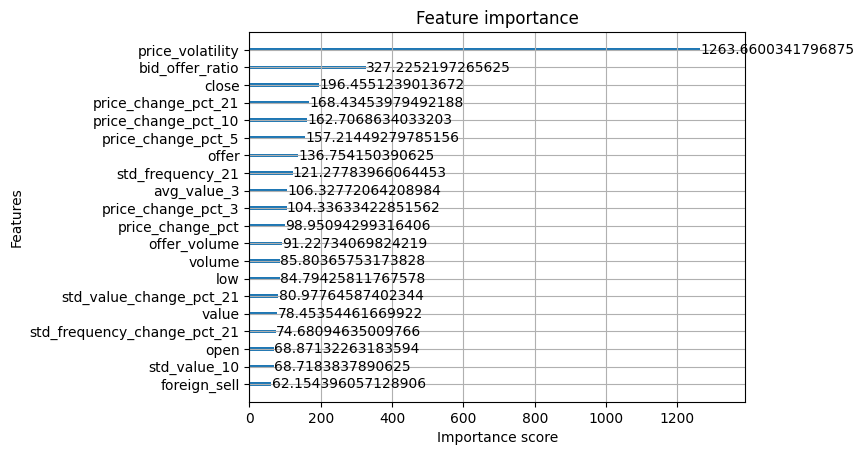

In [5]:
# Feature Importance
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.show()

C:\Users\rizbud\AppData\Local\Temp\ipykernel_16120\555608425.py:61: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  high = float(row['high'])
C:\Users\rizbud\AppData\Local\Temp\ipykernel_16120\555608425.py:62: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  low = float(row['low'])
C:\Users\rizbud\AppData\Local\Temp\ipykernel_16120\555608425.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  close = float(row['close'])
C:\Users\rizbud\AppData\Local\Temp\ipykernel_16120\555608425.py:64: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  next_open = float(row['next_open']) if not pd.isna(row['next_open'].va

Initial capital: 10,000,000
Final capital: 29,560,921
Highest capital: 29,560,921
Lowest capital: 9,657,119
Total PnL: 19,560,921
PnL %: 195.61%
Sharpe ratio: 2.70
Win rate: 44.20%
Max drawdown: -17.61%
Highest win: 837,904
Highest loss: -442,637
Total trades: 509
Total fee paid: 8,443,192

First 10 trades:


,ticker,buy_date,sell_date,buy_price,sell_price,shares,buy_value,sell_value,fee,pnl,pnl_pct,reason
0,INPC,2025-01-02,2025-01-03,216.00,205.20,13800,2980800.00,2831760.00,11550.60,-160590.60,-0.05,sl
1,PTIS,2025-01-02,2025-01-03,310.00,294.50,9600,2976000.00,2827200.00,11532.00,-160332.00,-0.05,sl
2,INPC,2025-01-03,2025-01-06,208.00,228.80,13900,2891200.00,3180320.00,12287.60,276832.40,0.10,tp
3,JIHD,2025-01-06,2025-01-07,1585.00,1743.50,700,1109500.00,1220450.00,4715.38,106234.63,0.10,tp
4,NINE,2025-01-03,2025-01-08,170.00,202.00,17000,2890000.00,3434000.00,12920.00,531080.00,0.18,timeout
5,NAYZ,2025-01-03,2025-01-08,74.00,81.40,39200,2900800.00,3190880.00,12328.40,277751.60,0.10,tp
6,PYFA,2025-01-07,2025-01-09,181.00,171.95,7000,1267000.00,1203650.00,4909.62,-68259.62,-0.05,sl
7,PZZA,2025-01-08,2025-01-09,157.00,172.70,18300,2873100.00,3160410.00,12210.68,275099.33,0.10,tp
8,INPC,2025-01-09,2025-01-10,266.00,292.60,9200,2447200.00,2691920.00,10400.60,234319.40,0.10,tp
9,CYBR,2025-01-08,2025-01-13,408.00,422.00,7000,2856000.00,2954000.00,11669.00,86331.00,0.03,timeout


Latest 10 trades:


,ticker,buy_date,sell_date,buy_price,sell_price,shares,buy_value,sell_value,fee,pnl,pnl_pct,reason
499,FIRE,2025-12-23,2025-12-24,157.00,172.70,35100,5510700.00,6061770.00,23420.48,527649.53,0.10,tp
500,ARKO,2025-12-23,2025-12-24,4860.00,4617.00,1100,5346000.00,5078700.00,20715.75,-288015.75,-0.05,sl
501,NETV,2025-12-24,2025-12-29,146.00,160.60,52100,7606600.00,8367260.00,32328.05,728331.95,0.10,tp
502,FIRE,2025-12-24,2025-12-29,155.00,169.00,49100,7610500.00,8297900.00,32160.50,655239.50,0.09,timeout
503,FILM,2025-12-24,2025-12-29,9950.00,10945.00,700,6965000.00,7661500.00,29601.25,666898.75,0.10,tp
504,FILM,2025-12-29,2025-12-30,12850.00,14135.00,600,7710000.00,8481000.00,32767.50,738232.50,0.10,tp
505,SOCI,2025-12-29,2025-12-30,520.00,494.00,15800,8216000.00,7805200.00,31837.00,-442637.00,-0.05,sl
506,MINA,2025-12-29,2026-01-02,378.00,415.80,21700,8202600.00,9022860.00,34861.05,785398.95,0.10,tp
507,SOCI,2025-12-30,2026-01-02,515.00,566.50,11300,5819500.00,6401450.00,24732.88,557217.12,0.10,tp
508,AHAP,2025-12-30,2026-01-02,117.00,128.70,49900,5838300.00,6422130.00,24812.78,559017.23,0.10,tp


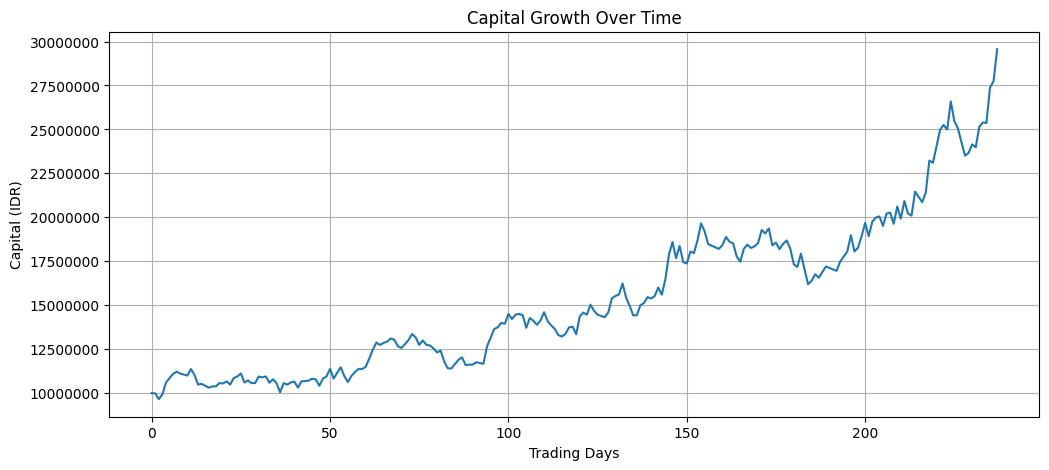

In [6]:
# Backtesting for 2025 data
import matplotlib.pyplot as plt

initial_capital = 10_000_000
capital = initial_capital
capital_curve = []
max_positions = 3
trade_size_pct = 0.3
lot_size = 100
buy_fee = 0.0015
sell_fee = 0.0025
min_avg_value = 1_000_000_000
take_profit = 1.10
stop_loss = 0.95

# Prepare test set with original columns
test_idx = df_prepared.index.get_level_values('date') >= '2025-01-01'
df_test = df.loc[test_idx].copy()

model = xgb.XGBClassifier()
model.load_model('xgboost_saham.json')
df_test['pred'] = model.predict(X_test)

# Sort by date for simulation
df_test = df_test.reset_index().sort_values(['date', 'ticker'])

# Helper for next trading day open price (not suspended)
df_test['next_open'] = df_test.groupby('ticker')['open'].shift(-1)
df_test['next_is_suspended'] = df_test.groupby('ticker')['is_suspended'].shift(-1)
# df_test['avg_value_5'] = df_test.groupby('ticker')['avg_value_5']

# Only consider buy signals (pred==1)
signals = df_test[
  (df_test['pred'] == 1) &
  (df_test['next_is_suspended'] == 0)
  # (df_test['next_avg_value_5'] >= min_avg_value)
]

# Track open positions: list of dicts
positions = []
trades = []
dates = sorted(df_test['date'].unique())

for date in dates:
    # Update capital curve
    capital_curve.append(capital + sum([p['current_value'] for p in positions]))

    # Update open positions: check exit conditions
    new_positions = []
    for pos in positions:
        ticker = pos['ticker']
        entry_date = pos['entry_date']
        holding_days = (pd.to_datetime(date) - pd.to_datetime(entry_date)).days
        # Get today's row for this ticker
        row = df_test[(df_test['date'] == date) & (df_test['ticker'] == ticker)]
        if row.empty:
            # No data, keep position
            pos['current_value'] = pos['shares'] * pos['entry_price']
            new_positions.append(pos)
            continue
        high = float(row['high'])
        low = float(row['low'])
        close = float(row['close'])
        next_open = float(row['next_open']) if not pd.isna(row['next_open'].values[0]) else close
        # Check exit: +10% or -5% from entry, or after 5 trading days
        target_up = pos['entry_price'] * take_profit
        target_down = pos['entry_price'] * stop_loss
        exit_reason = None
        if high >= target_up:
            exit_reason = 'tp'
        elif low <= target_down:
            exit_reason = 'sl'
        elif holding_days >= 5:
            exit_reason = 'timeout'
        if exit_reason:
            # Sell price logic
            if exit_reason == 'tp':
                sell_price = target_up
            elif exit_reason == 'sl':
                sell_price = target_down
            else:
                # timeout: use next day's open (if not suspended)
                sell_price = next_open
            sell_value = sell_price * pos['shares']
            buy_value = pos['entry_price'] * pos['shares']
            fee = buy_value * buy_fee + sell_value * sell_fee
            pnl = sell_value - buy_value - fee
            capital += sell_value - fee
            trades.append({
                'ticker': ticker,
                'buy_date': pos['entry_date'],
                'sell_date': date,
                'buy_price': pos['entry_price'],
                'sell_price': sell_price,
                'shares': pos['shares'],
                'buy_value': buy_value,
                'sell_value': sell_value,
                'fee': fee,
                'pnl': pnl,
                'pnl_pct': pnl / buy_value,
                'reason': exit_reason
            })
        else:
            # Mark to market
            pos['current_value'] = close * pos['shares']
            new_positions.append(pos)
    positions = new_positions

    # Open new positions if slots available
    open_slots = max_positions - len(positions)
    if open_slots > 0:
        # Get today's signals, sort by predicted probability if available
        todays_signals = signals[signals['date'] == date]
        # Avoid duplicate tickers
        todays_signals = todays_signals[~todays_signals['ticker'].isin([p['ticker'] for p in positions])]
        # sort by value descending
        todays_signals = todays_signals.sort_values(by='value', ascending=False)
        max_trade_value = capital * trade_size_pct
        for _, row in todays_signals.head(open_slots).iterrows():
            # Check capital for 1 lot
            buy_price = row['next_open']
            if pd.isna(buy_price) or buy_price <= 60 or row['value'] < min_avg_value:
                continue
            shares = int(max_trade_value // (buy_price * lot_size)) * lot_size
            if shares < lot_size:
                continue
            buy_value = buy_price * shares
            fee = buy_value * buy_fee
            total_cost = buy_value + fee
            if total_cost > capital:
                continue
            capital -= total_cost
            positions.append({
                'ticker': row['ticker'],
                'entry_date': row['date'],
                'entry_price': buy_price,
                'shares': shares,
                'current_value': buy_price * shares
            })

# Final mark-to-market for open positions
for pos in positions:
    sell_value = pos['current_value']
    buy_value = pos['entry_price'] * pos['shares']
    fee = buy_value * buy_fee + sell_value * sell_fee
    pnl = sell_value - buy_value - fee
    trades.append({
        'ticker': pos['ticker'],
        'buy_date': pos['entry_date'],
        'sell_date': dates[-1],
        'buy_price': pos['entry_price'],
        'sell_price': sell_value / pos['shares'],
        'shares': pos['shares'],
        'buy_value': buy_value,
        'sell_value': sell_value,
        'fee': fee,
        'pnl': pnl,
        'pnl_pct': pnl / buy_value,
        'reason': 'final_mtm'
    })
    capital += sell_value - fee
capital_curve.append(capital)

# Results summary
import pandas as pd
trades_df = pd.DataFrame(trades)
final_capital = capital
highest_capital = max(capital_curve)
lowest_capital = min(capital_curve)
total_pnl = final_capital - initial_capital
pnl_pct = total_pnl / initial_capital * 100
total_fee = trades_df['fee'].sum()
win_trades = trades_df[trades_df['pnl'] > 0]
lose_trades = trades_df[trades_df['pnl'] <= 0]
win_rate = len(win_trades) / len(trades_df) * 100 if len(trades_df) > 0 else 0
highest_win = trades_df['pnl'].max() if not trades_df.empty else 0
highest_loss = trades_df['pnl'].min() if not trades_df.empty else 0
total_trades = len(trades_df)

# Sharpe ratio (daily, risk-free = 0)
returns = pd.Series(capital_curve).pct_change().dropna()
sharpe = returns.mean() / returns.std() * (252 ** 0.5) if returns.std() > 0 else 0

# Max drawdown
cummax = pd.Series(capital_curve).cummax()
drawdown = pd.Series(capital_curve) / cummax - 1
max_drawdown = drawdown.min() * 100

print(f'Initial capital: {initial_capital:,.0f}')
print(f'Final capital: {final_capital:,.0f}')
print(f'Highest capital: {highest_capital:,.0f}')
print(f'Lowest capital: {lowest_capital:,.0f}')
print(f'Total PnL: {total_pnl:,.0f}')
print(f'PnL %: {pnl_pct:.2f}%')
print(f'Sharpe ratio: {sharpe:.2f}')
print(f'Win rate: {win_rate:.2f}%')
print(f'Max drawdown: {max_drawdown:.2f}%')
print(f'Highest win: {highest_win:,.0f}')
print(f'Highest loss: {highest_loss:,.0f}')
print(f'Total trades: {total_trades}')
print(f'Total fee paid: {total_fee:,.0f}')

print('\nFirst 10 trades:')
display(trades_df.head(10))
print('Latest 10 trades:')
display(trades_df.tail(10))

# Plot capital curve
plt.figure(figsize=(12,5))
plt.plot(capital_curve)
plt.ticklabel_format(style='plain', axis='both', useOffset=False)
plt.title('Capital Growth Over Time')
plt.xlabel('Trading Days')
plt.ylabel('Capital (IDR)')
plt.grid(True)
plt.show()